# Sklearn Linear Regression

In this section, we implement a **linear regression model using `sklearn`** to predict taxi demand at the zone-hour level. This complements the StatsModels OLS model and demonstrates a standard machine learning workflow, including train/test splitting and model evaluation.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
DATA_PATH = "../../data/processed/zone_hour_clusters.parquet"
df = pd.read_parquet(DATA_PATH)

# Target and features (same as before)
X = df[["hour", "day_of_week", "is_weekend", "avg_fare", "avg_distance"]]
y = df["demand"]

df

,zone_id,pickup_hour_ts,demand,avg_fare,avg_distance,hour,day_of_week,is_weekend,day,month,cluster
0,1,2019-01-01 10:00:00,2,61.250,16.900,10,1,0,1,1,3
1,1,2019-01-01 12:00:00,1,135.000,19.300,12,1,0,1,1,3
2,1,2019-01-01 15:00:00,1,106.000,41.280,15,1,0,1,1,3
3,1,2019-01-02 02:00:00,1,30.000,1.270,2,2,0,2,1,1
4,1,2019-01-02 03:00:00,1,15.000,12.650,3,2,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...
296802,265,2019-03-31 19:00:00,4,61.625,5.015,19,6,1,31,3,2
296803,265,2019-03-31 20:00:00,5,96.700,30.746,20,6,1,31,3,3
296804,265,2019-03-31 21:00:00,1,36.780,14.690,21,6,1,31,3,3
296805,265,2019-03-31 22:00:00,2,19.235,6.475,22,6,1,31,3,2


## **Train/Test Split**

The dataset is split into **80% training** and **20% testing** to evaluate out-of-sample performance.

In [9]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Initialize and fit model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

In [11]:
# R-squared
r2 = r2_score(y_test, y_pred)
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print(f"R² on test set: {r2:.3f}")
print(f"MSE on test set: {mse:.2f}")

R² on test set: 0.087
MSE on test set: 18624.00


In [12]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "sklearn_coef": lr.coef_
})

print(coef_df)

        feature  sklearn_coef
0          hour      3.565525
1   day_of_week      2.180918
2    is_weekend    -14.060406
3      avg_fare     -0.931948
4  avg_distance     -4.326914


## **Model Fitting and Evaluation**

We fit a linear regression model using `sklearn.linear_model.LinearRegression` and make predictions on the test set.

**Performance metrics:**

- **R² on test set:** 0.087  
  This indicates that ~8.7% of the variance in demand is explained by the model, similar to the OLS regression.  
- **Mean Squared Error (MSE):** 18,624  
  Captures the average squared deviation between predicted and actual demand.

**Interpretation of the model coefficients:**

- **hour (+3.57):** Demand increases as the day progresses, reflecting higher activity during daytime and evening hours.  
- **day_of_week (+2.18):** Slight increase in demand later in the week.  
- **is_weekend (-14.06):** Weekend demand is significantly lower than weekdays.  
- **avg_fare (-0.93):** Higher fares are associated with slightly lower ride frequency.  
- **avg_distance (-4.33):** Longer trips occur less frequently, reducing total demand.  

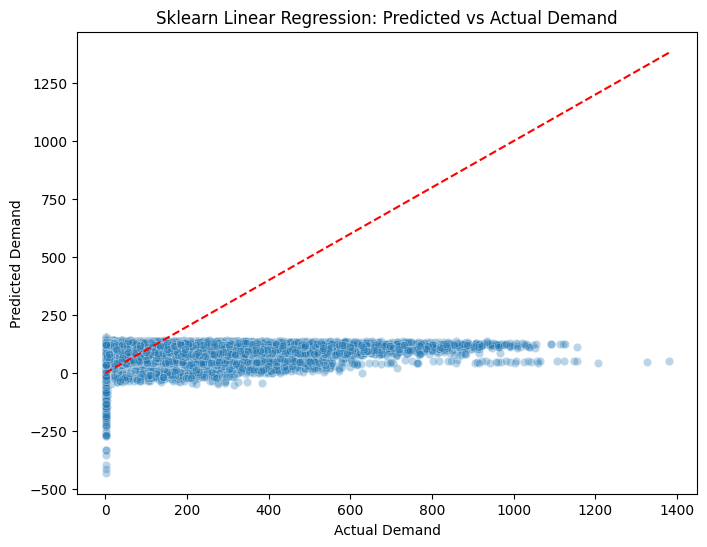

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Sklearn Linear Regression: Predicted vs Actual Demand")
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')  # 45-degree line
plt.show()




---

## **Predicted vs Actual Demand**

The scatter plot compares predicted and actual demand for the test set. Points close to the 45-degree line indicate accurate predictions.

---

### **Key Takeaways**

- The `sklearn` linear regression replicates the main insights from the OLS model.
- Coefficient signs and magnitudes are consistent, confirming the general influence of features on demand.
- The model has **limited predictive power**, highlighting that additional variables and non-linear modeling approaches would be needed for better forecasts.